# ðŸ”¬ Harmonic Math Sandbox (Tempo Class)
Testing the $O(1)$ logarithmic modulo space tracking in a simplified environment without complex jailbreak triggers.

In [95]:
import librosa
import numpy as np
import torchaudio
import torch
import time
from collections import deque
import warnings
warnings.filterwarnings('ignore')

import sys
import os
sys.path.append(os.path.abspath('../..'))
import core.Listener as ListenerModule
from IPython.display import display, clear_output

def default_infos():
    return {
        "startServer"     : False ,
        "useMicrophone"   : True  ,
        "HARDWARE_MODE"   : "simulation",
        "onRaspberry"     : False  ,
        "printTimeOfCalculation" : False ,
        "printModesDetails"      : True ,
        "printMicrophoneDetails" : False ,
        "printAppDetails"        : False ,
        "printAsservmentDetails" : False ,
        "printConfigurationLoads": False ,
        "printConfigChanges"     : False ,
        "modesToPrintDetails"    : ["PSG"]
    }



In [ ]:
import librosa
import numpy as np
import os
import json

root        = '../../assets/musics/mp3_files/'
DB_PATH     = os.path.join(root, 'bpm_database.json')

# Load the BPM database
with open(DB_PATH, 'r', encoding='utf-8') as _f:
    _bpm_db = json.load(_f)

# Select songs to test — edit this list freely.
# Only names that exist in bpm_database.json will work.
TEST_SONGS = [
    'Palladium',
    'Pumped Up Kicks',
    'Nobody Rules the Streets',
    'Another One Bites The Dust - Remastered 2011',
    "Stayin' Alive - From _Saturday Night Fever_ Soundtrack",
    'Boogie Wonderland',
    'Roxanne - Remastered 2003',
    'September',
]

SONGS      = [(name, _bpm_db[name]['bpm']) for name in TEST_SONGS if name in _bpm_db]
song_files = [root + name + '.mp3' for name, _ in SONGS]
real_bpms  = [bpm for _, bpm in SONGS]
song_names = [name for name, _ in SONGS]

librosa_dir = os.path.join(root, 'librosa')
os.makedirs(librosa_dir, exist_ok=True)

y_list = []
for f in song_files:
    basename  = os.path.basename(f)
    save_path = os.path.join(librosa_dir, f'{basename}.npz')
    if os.path.exists(save_path):
        data = np.load(save_path, allow_pickle=True)
        y = data['y']
    else:
        y, _ = librosa.load(f, sr=44100)
        np.savez(save_path, y=y, sr=44100)
    y_list.append(y)

print(f'BPM database: {len(_bpm_db)} songs total')
print(f'Testing {len(y_list)} songs:')
for i, (name, bpm) in enumerate(SONGS):
    src = _bpm_db[name].get('source', '?')
    dur = len(y_list[i]) / 44100.0
    print(f'  [{i+1}] {name[:50]:50s}  {dur:.1f}s  {bpm} BPM  [{src}]')


Loaded 8 songs.
  [1] Palladium                                                373.9s  target=172.2 BPM
  [2] Pumped Up Kicks                                          239.6s  target=128 BPM
  [3] Nobody Rules the Streets                                 267.5s  target=128 BPM
  [4] Another One Bites The Dust - Remastered 2011             214.7s  target=110 BPM
  [5] Stayin' Alive - From _Saturday Night Fever_ Soundtrack   285.4s  target=104 BPM
  [6] Boogie Wonderland                                        288.3s  target=132 BPM
  [7] Roxanne - Remastered 2003                                191.5s  target=134 BPM
  [8] September                                                214.8s  target=125 BPM


In [97]:
class Robust_Simulated_Microphone:
    def __init__(self, y_full_array, bandValues, infos):
        self.bandValues = bandValues
        self.nb_of_fft_band = len(self.bandValues)
        self.sample_rate = 44100
        self.buffer_size = 1024 
        self.audio_data = np.zeros(self.buffer_size)
        self.full_audio = y_full_array
        self.total_samples = len(self.full_audio)
        self.current_pos = 0
        fft_size = self.buffer_size // 2 + 1
        self.weight_matrix = np.zeros((self.nb_of_fft_band, fft_size))
        
        def hz_to_mel(f): return 2595 * np.log10(1 + f / 700.0)
        def mel_to_hz(m): return 700 * (10**(m / 2595.0) - 1)
        
        lower_mel = hz_to_mel(20)
        upper_mel = hz_to_mel(20000)
        mel_points = np.linspace(lower_mel, upper_mel, self.nb_of_fft_band + 2)
        hz_points = mel_to_hz(mel_points)
        bin_points = np.floor((self.buffer_size + 1) * hz_points / self.sample_rate).astype(int)
        
        for i in range(self.nb_of_fft_band):
            start = min(bin_points[i], fft_size - 1)
            mid = min(bin_points[i + 1], fft_size - 1)
            end = min(bin_points[i + 2], fft_size - 1)
            if mid > start:
                self.weight_matrix[i, start:mid] = np.linspace(0, 1, mid - start, endpoint=False)
            if end > mid:
                self.weight_matrix[i, mid:end] = np.linspace(1, 0, end - mid, endpoint=False)
            band_sum = np.sum(self.weight_matrix[i, :])
            if band_sum > 0:
                self.weight_matrix[i, :] /= band_sum
                
        self.raw_fft_history = None

    def pop_chunk(self, chunk_size=1024):
        if self.current_pos + chunk_size > self.total_samples:
            return False 
        incoming = self.full_audio[self.current_pos : self.current_pos + chunk_size]
        self.current_pos += chunk_size
        self.audio_data = np.roll(self.audio_data, -chunk_size)
        self.audio_data[-chunk_size:] = incoming
        return True

    def calculate_fft(self):
        windowed_data = self.audio_data * np.hanning(self.buffer_size)
        fft_result = np.abs(np.fft.rfft(windowed_data))
        scale = 150.0 / (self.buffer_size / 1024.0)
        mel_bands = np.dot(self.weight_matrix, fft_result) * scale
        for i in range(self.nb_of_fft_band):
            self.bandValues[i] = int(mel_bands[i])
        self.raw_fft_history = fft_result



In [98]:
# THE HARMONIC MATH CORE (SIMPLIFIED)
def bpm_to_class(bpm):
    '''Map BPM to a float in [0, 1) based on octave'''
    return np.log2(bpm / 60.0) % 1.0

def class_to_bpm_candidates(bpm_class):
    '''Returns the most common harmonic multipliers for a given class'''
    base_bpm = 60.0 * (2 ** bpm_class)
    return [
        base_bpm * 0.5,    # e.g., 50
        base_bpm * 0.75,   # e.g., 75
        base_bpm * 1.0,    # e.g., 100
        base_bpm * 1.5,    # e.g., 150
        base_bpm * 2.0     # e.g., 200
    ]

def tempo_class_distance(f1, f2):
    '''Shortest circular distance on [0, 1)'''
    d = abs(f1 - f2)
    return min(d, 1.0 - d)

def harmonic_alignment(current_class, long_term_class):
    '''Checks straight octaves AND perfect fifths (1.5x) to safely align and find distance'''
    shift = np.log2(1.5) # approx 0.58496
    d_oct = tempo_class_distance(current_class, long_term_class)
    d_fifth_up = tempo_class_distance(current_class, (long_term_class + shift) % 1.0)
    d_fifth_down = tempo_class_distance(current_class, (long_term_class - shift) % 1.0)
    
    min_d = min(d_oct, d_fifth_up, d_fifth_down)
    
    if min_d == d_oct:
        aligned_class = current_class
    elif min_d == d_fifth_up:
        aligned_class = (current_class - shift) % 1.0
    else:
        aligned_class = (current_class + shift) % 1.0
        
    return min_d, aligned_class



In [99]:
# THE TEMPLATE BANK (O(1) Precomputed Pearson Correlation)
class FastTemplateBank:
    def __init__(self, btrack_fps=60.0, odf_size=300):
        self.btrack_fps = btrack_fps
        self.odf_size = odf_size
        self.templates = {}
        
        buffer_indices = np.arange(self.odf_size)
        self.const_part = buffer_indices - (self.odf_size - 1)
        
    def get_template(self, bpm_val):
        if bpm_val in self.templates:
            return self.templates[bpm_val]
            
        tau_val = 60.0 * self.btrack_fps / bpm_val
        p_max = int(np.ceil(tau_val))
        
        p_arr = np.arange(p_max)[:, None]
        phase_float = (self.const_part[None, :] + p_arr) % tau_val
        norm_phi = phase_float / tau_val 
        
        # Sharp Triangle Pulse
        beat_dist = np.minimum(norm_phi, 1.0 - norm_phi)
        template_vals = np.full((p_max, self.odf_size), -1.0)
        mask_beat = beat_dist < 0.1
        template_vals[mask_beat] = 1.0 - (beat_dist[mask_beat] / 0.1)
        
        template_mean = np.mean(template_vals, axis=1, keepdims=True)
        template_centered = template_vals - template_mean
        template_std = np.sqrt(np.sum(template_centered**2, axis=1)) + 1e-6
        
        # Pre-normalized template for rapid matrix multiplication
        normalized_template = template_centered / template_std[:, None]
        self.templates[bpm_val] = normalized_template
        return normalized_template

# Global Bank Instance
template_bank = FastTemplateBank()

# THE CANDIDATE EVALUATOR (HEAVY JUDGE)
def evaluate_specific_bpms(odf_buffer, candidate_bpms, **kwargs):
    odf_size = len(odf_buffer)
    decay_curve = np.exp(-1.5 * np.linspace(1.0, 0.0, odf_size))
    weighted_buffer = odf_buffer * decay_curve
    
    # Pre-compute zero-mean buffer for Pearson
    buffer_mean = np.mean(weighted_buffer)
    buffer_centered = weighted_buffer - buffer_mean
    buffer_std = np.sqrt(np.sum(buffer_centered**2)) + 1e-6
    
    best_score_pearson = -float('inf')
    best_bpm_pearson = candidate_bpms[0]
    
    for bpm_val in candidate_bpms:
        if not (40.0 <= bpm_val <= 190.0):
            continue
            
        normalized_template = template_bank.get_template(bpm_val)
        
        # O(1) Vectorized Pearson Correlation via Dot Product
        p_scores_pearson = (normalized_template @ buffer_centered) / buffer_std
        
        # --- HUMAN PERCEPTION PRIOR (Gaussian weighting) ---
        human_prior = 0.5 + 0.5 * np.exp(-0.5 * ((bpm_val - 125.0) / 40.0)**2)
        weighted_score = np.max(p_scores_pearson) * human_prior
        
        if weighted_score > best_score_pearson:
            best_score_pearson = weighted_score
            best_bpm_pearson = bpm_val
            
    return best_bpm_pearson, best_score_pearson


In [100]:
# THE INITIAL SWEEP (FAST SCOUT) - TRUE PEARSON O(1)
def class_based_phase_sweep(odf_buffer, class_evals, **kwargs):
    odf_size = len(odf_buffer)
    decay_curve = np.exp(-1.5 * np.linspace(1.0, 0.0, odf_size))
    weighted_buffer = odf_buffer * decay_curve
    
    buffer_mean = np.mean(weighted_buffer)
    buffer_centered = weighted_buffer - buffer_mean
    buffer_std = np.sqrt(np.sum(buffer_centered**2)) + 1e-6
    
    best_overall_score = -float('inf')
    best_overall_class = class_evals[0] % 1.0
    
    for class_val in class_evals:
        c = class_val % 1.0
        base_bpm = 60.0 * (2 ** c)
        eval_bpm = base_bpm if base_bpm >= 90.0 else base_bpm * 2.0
        
        normalized_template = template_bank.get_template(eval_bpm)
        p_scores = (normalized_template @ buffer_centered) / buffer_std
        
        # Human Prior injected into Fast Scout to fix Song 3 polyrhythms!
        human_prior = 0.5 + 0.5 * np.exp(-0.5 * ((eval_bpm - 125.0) / 40.0)**2)
        tau_max_score = np.max(p_scores) * human_prior
        
        if tau_max_score > best_overall_score:
            best_overall_score = tau_max_score
            best_overall_class = c
            
    return best_overall_class, best_overall_score


In [101]:
# =====================================================================
# FAKE LISTENER - replaces the full Listener stack for simulation speed
# Only runs the 3 cheap AudioIngestion functions we actually need:
#   - update_band_means_and_smoothed_values
#   - asserv_fft_bands
#   - asserv_total_power
# Skips AudioAnalyzer entirely (no BTrack, no detect_band_peaks)
# =====================================================================

class FakeListener:
    NB_BANDS = 8

    def __init__(self):
        n = self.NB_BANDS
        self.fft_band_values     = np.zeros(n)
        self.smoothed_fft_band_values = np.zeros(n)
        self.band_means          = np.zeros(n)
        self.band_mean_distances = np.zeros(n)
        self.band_proportion     = np.zeros(n)
        self.band_lm             = np.ones(n) * 100.0
        self.band_gm             = np.ones(n) * 100.0
        self.asserved_fft_band   = np.zeros(n)
        self.smoothed_total_power  = 0.0
        self.asserved_total_power  = 0.0
        self.total_power_lm        = 100.0
        self.total_power_gm        = 100.0
        # stub attributes the simulation may read
        self.bpm = 120.0

    def update(self, fps_ratio=1.0):
        self._update_band_means(fps_ratio)
        self._asserv_fft_bands(fps_ratio)
        self._asserv_total_power(fps_ratio)

    # ---- copied & vectorized from AudioIngestion ----

    def _update_band_means(self, fps_ratio):
        attack  = 0.2  ** fps_ratio
        release = 0.85 ** fps_ratio
        smoothing = np.where(self.fft_band_values > self.smoothed_fft_band_values, attack, release)
        self.smoothed_fft_band_values = np.where(
            self.smoothed_fft_band_values < 1,
            self.fft_band_values,
            smoothing * self.smoothed_fft_band_values + (1 - smoothing) * self.fft_band_values
        )
        self.smoothed_fft_band_values = np.maximum(self.smoothed_fft_band_values, 0)

        retention = 0.999 ** fps_ratio
        self.band_means = np.where(
            self.band_means < 1,
            self.smoothed_fft_band_values,
            retention * self.band_means + (1 - retention) * self.smoothed_fft_band_values
        )
        self.band_means = np.maximum(self.band_means, 0)

        distances_target = np.abs(self.smoothed_fft_band_values - self.band_means)
        self.band_mean_distances = np.where(
            self.band_mean_distances < 1,
            self.smoothed_fft_band_values / 2.0,
            retention * self.band_mean_distances + (1 - retention) * distances_target
        )

        total = np.sum(self.smoothed_fft_band_values)
        if total > 0:
            self.band_proportion = self.smoothed_fft_band_values / total
        else:
            self.band_proportion.fill(0.0)

    def _asserv_fft_bands(self, fps_ratio):
        for i in range(self.NB_BANDS):
            sv = self.smoothed_fft_band_values[i]
            if sv >= self.band_lm[i]:
                self.band_lm[i] = sv
            else:
                self.band_lm[i] *= 0.9995 ** fps_ratio
            if sv >= self.band_gm[i]:
                self.band_gm[i] = 1.01 * sv
            else:
                self.band_gm[i] *= 1 + (0.005 * fps_ratio) * (self.band_lm[i] / max(0.001, self.band_gm[i]) - 0.9)
            self.asserved_fft_band[i] += min(1.0, 0.4 * fps_ratio) * (sv / self.band_gm[i] - self.asserved_fft_band[i])

    def _asserv_total_power(self, fps_ratio):
        instant = np.sum(self.fft_band_values)
        r = 0.5 ** fps_ratio
        self.smoothed_total_power = r * self.smoothed_total_power + (1 - r) * instant
        if self.smoothed_total_power > self.total_power_lm:
            self.total_power_lm = self.smoothed_total_power
        else:
            self.total_power_lm *= 0.9998 ** fps_ratio
        if self.smoothed_total_power > self.total_power_gm:
            self.total_power_gm = 1.01 * self.smoothed_total_power
        else:
            self.total_power_gm *= 1 + (0.005 * fps_ratio) * (self.total_power_lm / self.total_power_gm - 0.9)
        self.asserved_total_power += min(1.0, 0.4 * fps_ratio) * (self.smoothed_total_power / self.total_power_gm - self.asserved_total_power)

print('FakeListener defined.')


FakeListener defined.


In [102]:
import time as _time_module
def run_simulation(y_list):
    print('Starting Onset-Driven Simulation with FakeListener...')

    SIMULATED_FPS = 60.0
    TIME_PER_FRAME = 1.0 / SIMULATED_FPS
    CHUNK_SIZE = int(44100 / SIMULATED_FPS)

    listener = FakeListener()
    y_full   = np.concatenate(y_list)

    # ---- Simulated Microphone (Mel-filter) ----
    NB_BANDS    = FakeListener.NB_BANDS
    BUFFER_SIZE = 1024
    SR          = 44100
    audio_buffer = np.zeros(BUFFER_SIZE)
    fft_size     = BUFFER_SIZE // 2 + 1

    def hz_to_mel(f): return 2595 * np.log10(1 + f / 700.0)
    def mel_to_hz(m): return 700 * (10**(m / 2595.0) - 1)
    lower_mel = hz_to_mel(20);  upper_mel = hz_to_mel(20000)
    mel_pts   = np.linspace(lower_mel, upper_mel, NB_BANDS + 2)
    hz_pts    = mel_to_hz(mel_pts)
    bin_pts   = np.floor((BUFFER_SIZE + 1) * hz_pts / SR).astype(int)
    W = np.zeros((NB_BANDS, fft_size))
    for i in range(NB_BANDS):
        s, m, e = (min(bin_pts[i+k], fft_size-1) for k in range(3))
        if m > s: W[i, s:m] = np.linspace(0, 1, m-s, endpoint=False)
        if e > m: W[i, m:e] = np.linspace(1, 0, e-m, endpoint=False)
        tot = W[i].sum()
        if tot > 0: W[i] /= tot
    hanning = np.hanning(BUFFER_SIZE)

    # ---- Tracking state ----
    history_time, history_raw_bpm, history_pearson, history_class, history_ltm_class = [], [], [], [], []
    playhead_time = 0.0
    frame = 0
    pos = 0

    last_strong_sweep_time = -8.0
    smoothed_flux  = 0.0
    long_term_class = 0.0
    custom_odf_buffer = np.zeros(300)
    prev_bands = np.zeros(NB_BANDS)

    best_class  = 0.0
    bpm_pearson = 120.0

    # Profiling
    profile = {'ingestion': 0.0, 'listener_update': 0.0, 'flux': 0.0,
               'scout': 0.0, 'alignment': 0.0, 'judge': 0.0}
    pc = _time_module.perf_counter

    while pos + CHUNK_SIZE <= len(y_full):
        # --- Mic ingestion ---
        t0 = pc()
        chunk = y_full[pos: pos + CHUNK_SIZE]; pos += CHUNK_SIZE
        audio_buffer = np.roll(audio_buffer, -CHUNK_SIZE)
        audio_buffer[-CHUNK_SIZE:] = chunk
        fft_result = np.abs(np.fft.rfft(audio_buffer * hanning))
        mel = np.dot(W, fft_result) * (150.0 / (BUFFER_SIZE / 1024.0))
        listener.fft_band_values[:] = mel.astype(int)
        profile['ingestion'] += pc() - t0

        # --- FakeListener update ---
        t0 = pc()
        listener.update(fps_ratio=1.0)
        profile['listener_update'] += pc() - t0

        # --- Flux + onset detection ---
        t0 = pc()
        current_bands = np.array(listener.fft_band_values)
        flux_bands    = np.maximum(0, current_bands - prev_bands)
        prev_bands    = current_bands
        custom_flux   = np.sum(flux_bands[0:2]) + np.sum(flux_bands[-2:])
        custom_odf_buffer = np.roll(custom_odf_buffer, -1)
        custom_odf_buffer[-1] = custom_flux
        smoothed_flux = 0.95 * smoothed_flux + 0.05 * custom_flux
        is_peak = custom_flux > (smoothed_flux * 1.8 + 0.1)
        profile['flux'] += pc() - t0

        if is_peak:
            if playhead_time - last_strong_sweep_time >= 8.0:
                class_evals = np.arange(0.0, 1.0, 0.01)
                last_strong_sweep_time = playhead_time
            else:
                class_evals = np.arange(long_term_class - 0.05, long_term_class + 0.05 + 0.001, 0.01)

            # 1. FAST SCOUT
            t0 = pc()
            best_class, _ = class_based_phase_sweep(custom_odf_buffer, class_evals)
            profile['scout'] += pc() - t0

            # 2. FLYWHEEL UPDATE FROM SCOUT (weak, harmonic-aware)
            t0 = pc()
            min_d, aligned_class = harmonic_alignment(best_class, long_term_class)
            if playhead_time < 5.0:
                long_term_class = aligned_class
            else:
                diff = (aligned_class - long_term_class + 0.5) % 1.0 - 0.5
                long_term_class = (long_term_class + 0.1 * diff) % 1.0
            candidates = class_to_bpm_candidates(long_term_class)
            profile['alignment'] += pc() - t0

            # 3. HEAVY JUDGE
            t0 = pc()
            bpm_pearson, score_pearson = evaluate_specific_bpms(custom_odf_buffer, candidates)
            profile['judge'] += pc() - t0

            # 4. FLYWHEEL UPDATE FROM JUDGE (strong, DIRECT - no harmonic alignment)
            # The Judge already evaluated multiple harmonics and picked the best one.
            # Applying harmonic_alignment here maps the correct class BACK to the
            # wrong flywheel class via fifth-aliasing (the Stayin' Alive bug).
            # Instead, pull directly toward the Judge's class with a strong step.
            winning_class = bpm_to_class(bpm_pearson)
            diff_win = (winning_class - long_term_class + 0.5) % 1.0 - 0.5
            long_term_class = (long_term_class + 0.5 * diff_win) % 1.0

            listener.bpm = bpm_pearson

        if frame % int(SIMULATED_FPS) == 0:
            history_time.append(playhead_time)
            history_raw_bpm.append(60.0 * (2 ** best_class))
            history_pearson.append(bpm_pearson)
            history_class.append(best_class)
            history_ltm_class.append(long_term_class)

        playhead_time += TIME_PER_FRAME
        frame += 1

    print('Simulation Complete!')
    print('\n=== PROFILING RESULTS ===')
    for k, v in profile.items():
        print(f'  {k:25s}: {v:.3f} s')
    return history_time, history_raw_bpm, history_pearson, history_class, history_ltm_class


Starting Onset-Driven Simulation with FakeListener...
Simulation Complete!

=== PROFILING RESULTS ===
  ingestion                : 6.964 s
  listener_update          : 10.921 s
  flux                     : 5.488 s
  scout                    : 49.874 s
  alignment                : 0.207 s
  judge                    : 22.617 s
[1/8] Palladium                                      dur=373.9s  compile=96.8s  ratio=0.259  median=118.2 BPM  err=31.4%
Starting Onset-Driven Simulation with FakeListener...
Simulation Complete!

=== PROFILING RESULTS ===
  ingestion                : 2.217 s
  listener_update          : 3.661 s
  flux                     : 1.665 s
  scout                    : 8.172 s
  alignment                : 0.071 s
  judge                    : 8.034 s
[2/8] Pumped Up Kicks                                dur=239.6s  compile=24.0s  ratio=0.100  median=127.9 BPM  err=0.0%
Starting Onset-Driven Simulation with FakeListener...
Simulation Complete!

=== PROFILING RESULTS ===
  inge

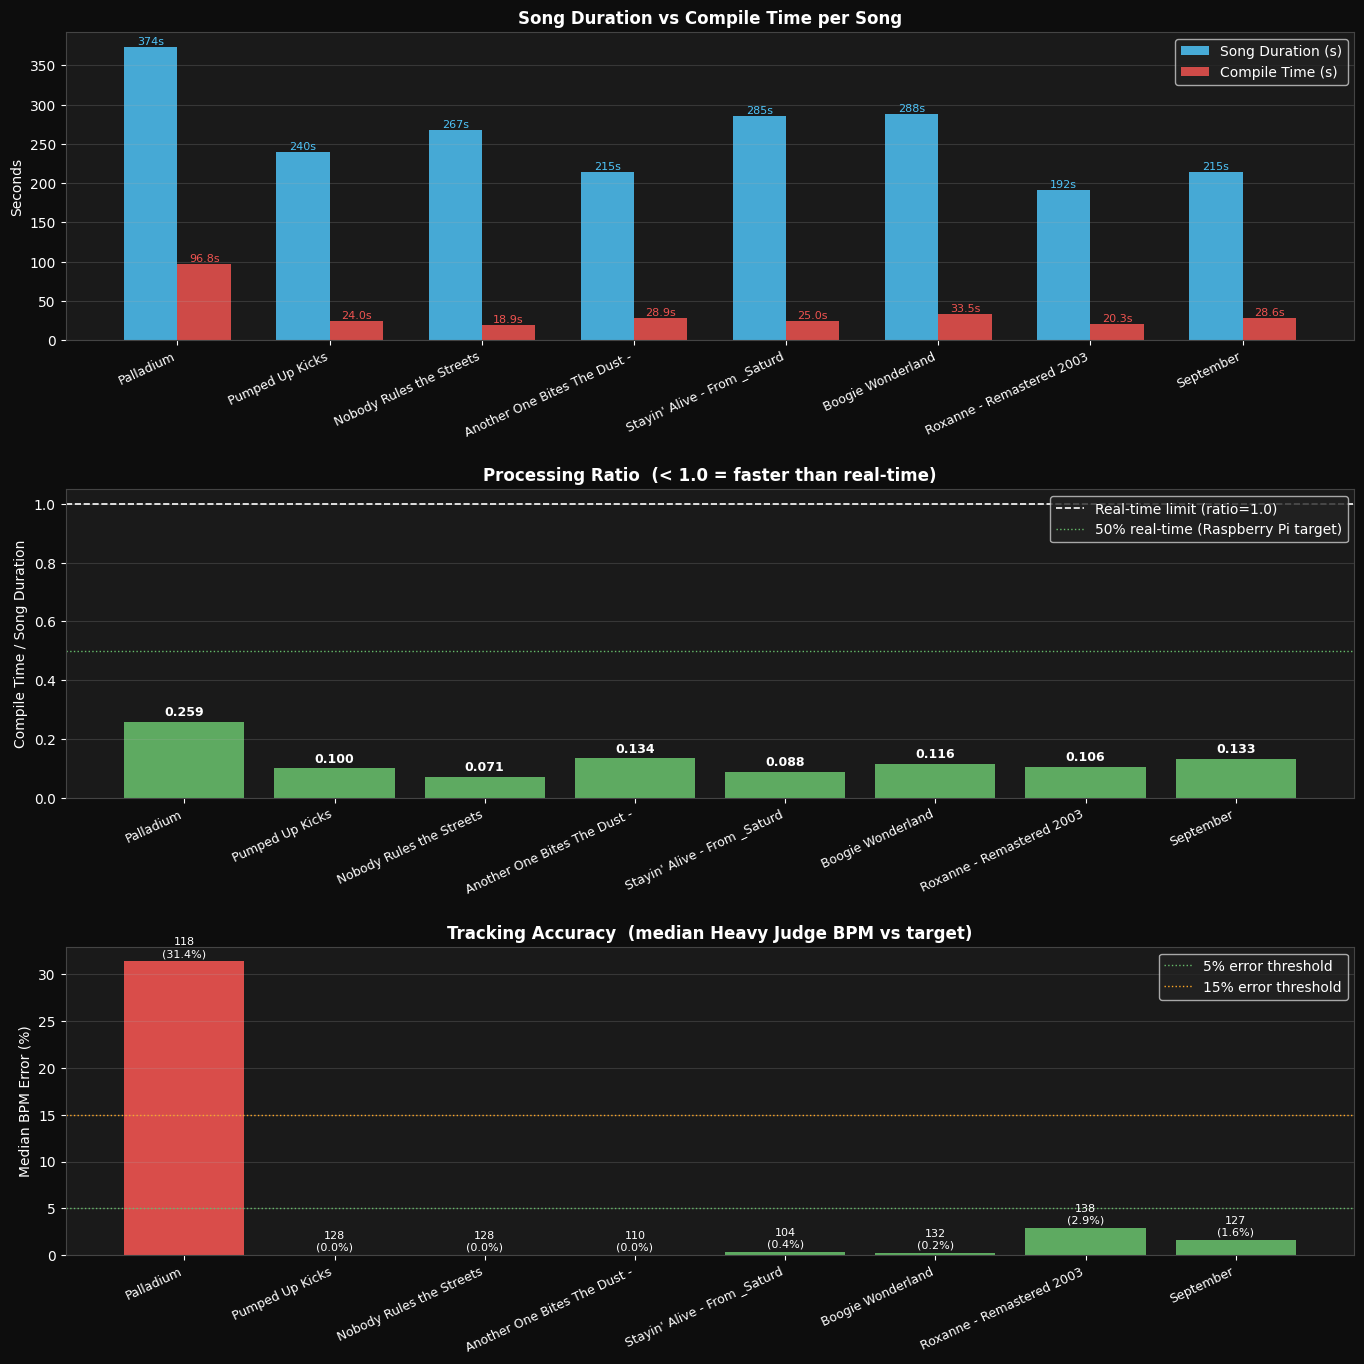

Saved: multi_song_profiling.png


In [104]:
import time as _time_module
import matplotlib.pyplot as plt

# Run each song INDEPENDENTLY and collect per-song metrics
results = []  # list of dicts

for song_idx, (y, target_bpm, sname) in enumerate(zip(y_list, real_bpms, song_names)):
    song_duration = len(y) / 44100.0
    t_wall_start  = _time_module.perf_counter()

    h_time, h_raw_bpm, h_pearson, h_class, h_ltm_class = run_simulation([y])

    t_wall_end   = _time_module.perf_counter()
    compile_time = t_wall_end - t_wall_start
    ratio        = compile_time / song_duration

    # Accuracy: median of last 50% of heavy-judge BPM vs target
    mid = len(h_pearson) // 2
    median_bpm = float(np.median(h_pearson[mid:]))
    error_pct  = abs(median_bpm - target_bpm) / target_bpm * 100.0

    results.append({
        'name':          sname,
        'target_bpm':    target_bpm,
        'song_duration': song_duration,
        'compile_time':  compile_time,
        'ratio':         ratio,
        'median_bpm':    median_bpm,
        'error_pct':     error_pct,
        'h_time':        h_time,
        'h_pearson':     h_pearson,
        'h_raw_bpm':     h_raw_bpm,
        'h_ltm_class':   h_ltm_class,
    })
    print(f'[{song_idx+1}/{len(y_list)}] {sname[:45]:45s}  '
          f'dur={song_duration:.1f}s  '
          f'compile={compile_time:.1f}s  '
          f'ratio={ratio:.3f}  '
          f'median={median_bpm:.1f} BPM  '
          f'err={error_pct:.1f}%')

# ── PLOT 1: Song duration & compile time (bar chart) ──────────────────────
labels        = [r['name'][:28] for r in results]
durations     = [r['song_duration']  for r in results]
compile_times = [r['compile_time']   for r in results]
ratios        = [r['ratio']          for r in results]
errors        = [r['error_pct']      for r in results]

fig, axes = plt.subplots(3, 1, figsize=(14, 14))
fig.patch.set_facecolor('#0d0d0d')
for ax in axes:
    ax.set_facecolor('#1a1a1a')
    ax.tick_params(colors='white')
    ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')
    ax.title.set_color('white')
    for spine in ax.spines.values():
        spine.set_edgecolor('#444')

x = range(len(results))

# -- Bar: durations vs compile time --
ax = axes[0]
width = 0.35
bars1 = ax.bar([i - width/2 for i in x], durations,     width, label='Song Duration (s)',  color='#4fc3f7', alpha=0.85)
bars2 = ax.bar([i + width/2 for i in x], compile_times, width, label='Compile Time (s)',   color='#ef5350', alpha=0.85)
ax.set_xticks(list(x))
ax.set_xticklabels(labels, rotation=25, ha='right', fontsize=9, color='white')
ax.set_ylabel('Seconds', color='white')
ax.set_title('Song Duration vs Compile Time per Song', fontsize=12, fontweight='bold')
ax.legend(facecolor='#222', labelcolor='white')
ax.grid(axis='y', alpha=0.2)
for bar in bars1: ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5, f'{bar.get_height():.0f}s', ha='center', va='bottom', color='#4fc3f7', fontsize=8)
for bar in bars2: ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5, f'{bar.get_height():.1f}s', ha='center', va='bottom', color='#ef5350', fontsize=8)

# -- Bar: compile_time / song_duration ratio --
ax = axes[1]
bar_colors = ['#66bb6a' if r < 0.5 else '#ffa726' if r < 1.0 else '#ef5350' for r in ratios]
bars = ax.bar(x, ratios, color=bar_colors, alpha=0.9)
ax.axhline(1.0, color='white', linestyle='--', linewidth=1.2, label='Real-time limit (ratio=1.0)')
ax.axhline(0.5, color='#66bb6a', linestyle=':', linewidth=1.0, label='50% real-time (Raspberry Pi target)')
ax.set_xticks(list(x))
ax.set_xticklabels(labels, rotation=25, ha='right', fontsize=9, color='white')
ax.set_ylabel('Compile Time / Song Duration', color='white')
ax.set_title('Processing Ratio  (< 1.0 = faster than real-time)', fontsize=12, fontweight='bold')
ax.legend(facecolor='#222', labelcolor='white')
ax.grid(axis='y', alpha=0.2)
for bar, r in zip(bars, ratios): ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01, f'{r:.3f}', ha='center', va='bottom', color='white', fontsize=9, fontweight='bold')

# -- Bar: accuracy error % per song --
ax = axes[2]
err_colors = ['#66bb6a' if e < 5 else '#ffa726' if e < 15 else '#ef5350' for e in errors]
bars = ax.bar(x, errors, color=err_colors, alpha=0.9)
ax.axhline(5.0,  color='#66bb6a', linestyle=':', linewidth=1.0, label='5% error threshold')
ax.axhline(15.0, color='#ffa726', linestyle=':', linewidth=1.0, label='15% error threshold')
ax.set_xticks(list(x))
ax.set_xticklabels(labels, rotation=25, ha='right', fontsize=9, color='white')
ax.set_ylabel('Median BPM Error (%)', color='white')
ax.set_title('Tracking Accuracy  (median Heavy Judge BPM vs target)', fontsize=12, fontweight='bold')
ax.legend(facecolor='#222', labelcolor='white')
ax.grid(axis='y', alpha=0.2)

for bar, res in zip(bars, results):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f'{res["median_bpm"]:.0f}\n({res["error_pct"]:.1f}%)',
            ha='center', va='bottom', color='white', fontsize=8)

plt.tight_layout(pad=2.0)
plt.savefig('multi_song_profiling.png', dpi=120, facecolor='#0d0d0d')
plt.show()
print('Saved: multi_song_profiling.png')


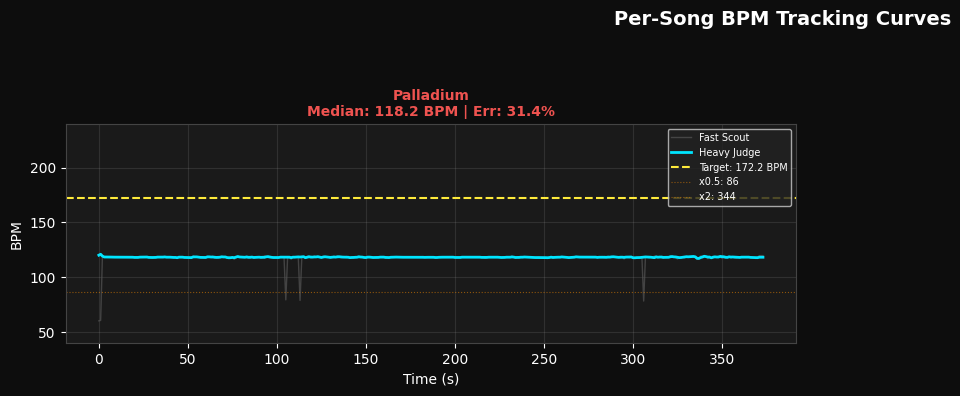

Saved: per_song_curves.png


In [106]:
import matplotlib.pyplot as plt
import numpy as np

n_songs = len(results)
ncols = 2
nrows = (n_songs + 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 4))
fig.patch.set_facecolor('#0d0d0d')
axes = axes.flatten()

for idx, res in enumerate(results):
    ax = axes[idx]
    ax.set_facecolor('#1a1a1a')
    ax.tick_params(colors='white')
    ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')
    ax.title.set_color('white')
    for spine in ax.spines.values():
        spine.set_edgecolor('#444')

    t          = res['h_time']
    raw_bpm    = res['h_raw_bpm']
    judge_bpm  = res['h_pearson']
    target     = res['target_bpm']
    name       = res['name']
    median_bpm = res['median_bpm']
    err        = res['error_pct']

    ax.plot(t, raw_bpm,   color='#555555', linewidth=1.0, alpha=0.7, label='Fast Scout')
    ax.plot(t, judge_bpm, color='#00e5ff', linewidth=2.0, label='Heavy Judge')
    ax.axhline(target, color='#ffeb3b', linestyle='--', linewidth=1.5,
               label=f'Target: {target} BPM')

    # Harmonic lines (x0.5, x2)
    ax.axhline(target * 0.5, color='#ff8f00', linestyle=':', linewidth=0.8, alpha=0.5, label=f'x0.5: {target*0.5:.0f}')
    ax.axhline(target * 2.0, color='#ff8f00', linestyle=':', linewidth=0.8, alpha=0.5, label=f'x2: {target*2.0:.0f}')

    # Error annotation
    err_color = '#66bb6a' if err < 5 else '#ffa726' if err < 15 else '#ef5350'
    ax.set_title(f'{name[:40]}\nMedian: {median_bpm:.1f} BPM | Err: {err:.1f}%',
                 fontsize=10, fontweight='bold', color=err_color)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('BPM')
    ax.set_ylim(40, 240)
    ax.grid(True, alpha=0.15)
    ax.legend(fontsize=7, facecolor='#222', labelcolor='white', loc='upper right')

# Hide any spare axes
for idx in range(n_songs, len(axes)):
    axes[idx].set_visible(False)

fig.suptitle('Per-Song BPM Tracking Curves', fontsize=14, fontweight='bold', color='white', y=1.01)
plt.tight_layout(pad=2.0)
plt.savefig('per_song_curves.png', dpi=110, facecolor='#0d0d0d', bbox_inches='tight')
plt.show()
print('Saved: per_song_curves.png')


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def bpm_to_class(bpm):
    return np.log2(bpm / 60.0) % 1.0

def circular_distance(a, b):
    '''Shortest distance on the circular [0, 1) space'''
    d = np.abs(np.asarray(a) - b)
    return np.minimum(d, 1.0 - d)

n_songs = len(results)
ncols = 2
nrows = (n_songs + 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 4))
fig.patch.set_facecolor('#0d0d0d')
axes = axes.flatten()

for idx, res in enumerate(results):
    ax = axes[idx]
    ax.set_facecolor('#1a1a1a')
    ax.tick_params(colors='white')
    ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')
    ax.title.set_color('white')
    for spine in ax.spines.values():
        spine.set_edgecolor('#444')

    t           = np.array(res['h_time'])
    ltm_class   = np.array(res['h_ltm_class'])
    judge_bpm   = np.array(res['h_pearson'])
    target      = res['target_bpm']
    name        = res['name']

    target_class = bpm_to_class(target)

    # Class error of the Flywheel (long_term_class) vs target
    ltm_err  = circular_distance(ltm_class, target_class)

    # Class error of the Heavy Judge output vs target
    judge_class     = np.array([bpm_to_class(b) for b in judge_bpm])
    # Harmonic-aware: also check x0.5 and x2 octaves
    judge_class_h05 = np.array([bpm_to_class(b * 0.5) for b in judge_bpm])
    judge_class_h2  = np.array([bpm_to_class(b * 2.0) for b in judge_bpm])
    judge_err = np.minimum(
        circular_distance(judge_class, target_class),
        np.minimum(
            circular_distance(judge_class_h05, target_class),
            circular_distance(judge_class_h2,  target_class)
        )
    )

    ax.fill_between(t, ltm_err,  alpha=0.25, color='#42a5f5')
    ax.plot(t, ltm_err,   color='#42a5f5', linewidth=1.5, label='Flywheel (LTM) class error')
    ax.fill_between(t, judge_err, alpha=0.2, color='#00e5ff')
    ax.plot(t, judge_err, color='#00e5ff', linewidth=2.0, label='Heavy Judge class error (harmonic-aware)')

    ax.axhline(0.05, color='#66bb6a', linestyle=':', linewidth=1.0, label='0.05 tolerance (Local Sweep radius)')

    # Median error annotation
    med_err = float(np.median(judge_err[len(judge_err)//2:]))
    err_color = '#66bb6a' if med_err < 0.05 else '#ffa726' if med_err < 0.15 else '#ef5350'

    ax.set_title(
        f'{name[:40]}\nTarget class: {target_class:.3f}  |  Median err: {med_err:.4f}',
        fontsize=10, fontweight='bold', color=err_color
    )
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Circular Class Distance [0, 0.5]')
    ax.set_ylim(-0.01, 0.52)
    ax.grid(True, alpha=0.15)
    ax.legend(fontsize=7, facecolor='#222', labelcolor='white', loc='upper right')

for idx in range(n_songs, len(axes)):
    axes[idx].set_visible(False)

fig.suptitle('BPM Class Error Over Time (circular distance from target class)',
             fontsize=14, fontweight='bold', color='white', y=1.01)
plt.tight_layout(pad=2.0)
plt.savefig('class_error_curves.png', dpi=110, facecolor='#0d0d0d', bbox_inches='tight')
plt.show()
print('Saved: class_error_curves.png')


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# BPM → class helper (needed here in case kernel was partially run)
def _bpm_to_class(bpm):
    return np.log2(float(bpm) / 60.0) % 1.0

def _circular_dist(a, b):
    d = np.abs(np.asarray(a, float) - float(b))
    return np.minimum(d, 1.0 - d)

n_songs = len(results)
ncols = 2
nrows = (n_songs + 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 4))
fig.patch.set_facecolor('#0d0d0d')
axes = axes.flatten()

for idx, res in enumerate(results):
    ax = axes[idx]
    ax.set_facecolor('#1a1a1a')
    ax.tick_params(colors='white')
    ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')
    ax.title.set_color('white')
    for sp in ax.spines.values(): sp.set_edgecolor('#444')

    t           = np.array(res['h_time'])
    ltm_class   = np.array(res['h_ltm_class'])     # Flywheel (smoothed)
    scout_class = np.array(res['h_class'])          # Raw Fast Scout class
    target      = res['target_bpm']
    name        = res['name']

    # Target class — and its harmonic aliases
    tc      = _bpm_to_class(target)
    tc_half = _bpm_to_class(target * 0.5)
    tc_dbl  = _bpm_to_class(target * 2.0)

    ax.scatter(t, scout_class, s=2, color='#555555', alpha=0.4, label='Fast Scout class')
    ax.plot(t, ltm_class, color='#69f0ae', linewidth=2.0, label='Flywheel LTM class')

    # Target class lines
    ax.axhline(tc,      color='#ffeb3b', linestyle='--', linewidth=1.5,
               label=f'Target class {tc:.3f}  ({target:.1f} BPM)')
    ax.axhline(tc_half, color='#ff8f00', linestyle=':',  linewidth=1.0, alpha=0.7,
               label=f'x0.5 class  {tc_half:.3f}  ({target*0.5:.1f} BPM)')
    ax.axhline(tc_dbl,  color='#ff8f00', linestyle=':',  linewidth=1.0, alpha=0.7,
               label=f'x2   class  {tc_dbl:.3f}  ({target*2.0:.1f} BPM)')

    # Compute median class error (harmonic-aware)
    mid = len(ltm_class) // 2
    late_ltm = ltm_class[mid:]
    class_err = np.minimum(
        _circular_dist(late_ltm, tc),
        np.minimum(
            _circular_dist(late_ltm, tc_half),
            _circular_dist(late_ltm, tc_dbl)
        )
    )
    med_class_err = float(np.median(class_err))
    err_color = '#69f0ae' if med_class_err < 0.05 else '#ffa726' if med_class_err < 0.15 else '#ef5350'

    ax.set_title(
        f'{name[:42]}\n'
        f'Target class={tc:.3f}  |  Median class err={med_class_err:.4f}',
        fontsize=9, fontweight='bold', color=err_color
    )
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('BPM Class  [0, 1)')
    ax.set_ylim(-0.02, 1.02)
    ax.grid(True, alpha=0.12)
    ax.legend(fontsize=7, facecolor='#222', labelcolor='white', loc='lower right')

for idx in range(n_songs, len(axes)):
    axes[idx].set_visible(False)

fig.suptitle(
    'Log BPM Class Tracking  (circular [0, 1) space)\n'
    'Yellow = target class | Orange dotted = harmonic aliases',
    fontsize=13, fontweight='bold', color='white', y=1.01
)
plt.tight_layout(pad=2.0)
plt.savefig('log_bpm_class_curves.png', dpi=110, facecolor='#0d0d0d', bbox_inches='tight')
plt.show()
print('Saved: log_bpm_class_curves.png')
